# SCH-MGMT 661: Applications of AI Models  
**Instructor:** Indika Dissanayake  

---
### Tutorial: Transfer Learning for Image Classification (using MobileNetV2 and Keras)

---

### Dataset: CIFAR-10 Dataset  

The CIFAR-10 dataset is a collection of **60,000 color images** across **10 classes**, widely used for training machine learning and computer vision algorithms.

- Each image is:
  - Size: **32 x 32 pixels**
  - Channels: **RGB (3 channels)**

- Dataset Composition:
  - **50,000 training images**
  - **10,000 test images**
  - 10 classes (6,000 images per class)

-  **Classes**:
  0. airplane  
  1. automobile  
  2. bird  
  3. cat  
  4. deer  
  5. dog  
  6. frog  
  7. horse  
  8. ship  
  9. truck

---
### Why Transfer Learning?

Instead of training from scratch, transfer learning allows us to use a model (e.g., MobileNetV2) that has already been trained on a large dataset (ImageNet).
This pretrained model has already learned useful visual features like edges, shapes, and textures — which we can reuse for CIFAR-10.

We'll resize CIFAR-10 images to 96x96 pixels, freeze the pretrained layers, and add our own classification head for the 10 CIFAR-10 classes.

---
### Objective

By the end of this tutorial, you will be able to:
- Resize CIFAR-10 images for pretrained networks.
- Load and customize a pretrained MobileNetV3 model.
- Fine-tune the model on CIFAR-10.
- Evaluate and compare transfer learning vs. CNN-from-scratch performance.

---
💡 Tip: Before running the notebook, go to Runtime → Change runtime type → Hardware accelerator → GPU to speed up CNN training. If you face memory issues, try reducing the batch size (e.g., from 32 to 16).

# ***Transfer Leaning Approaches (Feature Extraction)***

## **Step 1: Data Loading, Preparation, and Image Resizing**

Before using a pretrained model like MobileNetV2, we must ensure our input data matches the format the model expects.
CIFAR-10 images are only 32 × 32, so we need to resize them and normalize pixel values.

- Load the dataset
- Resize to 96x96 and normalized
- One-hot encode the labels

### Importing Necessary Libraries and Loading Data

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, utils
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.datasets import cifar10 # Added import for cifar10

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [2]:
print(f"Original data shape: {x_train.shape}")

Original data shape: (50000, 32, 32, 3)


### Image Resizing

Resize Function:
- Uses tf.image.resize() to upscale from 32x32 to 96x96
- Normalizes pixel values by dividing by 255.0

Batch Processing:
- Processes images in batches of 1000 to avoid memory issues
- Uses tf.concat() to combine all batches

Result: x_train_resized.shape = (50000, 96, 96, 3)

In [3]:
# Resize CIFAR-10 images to 96x96 in batches
def resize_batch(images, target_size=(96, 96)):
    return tf.image.resize(images, target_size) / 255.0

# Batch processing helps avoid OOM (Out of Memory) errors

batch_size = 1000  # Start with 1000, reduce if OOM occurs
x_train_resized = tf.concat([
    resize_batch(x_train[i:i+batch_size])
    for i in range(0, len(x_train), batch_size)
], axis=0)

x_test_resized = tf.concat([
    resize_batch(x_test[i:i+batch_size])
    for i in range(0, len(x_test), batch_size)
], axis=0)

In [4]:
print(f"Resized data shape: {x_train_resized.shape}")

Resized data shape: (50000, 96, 96, 3)


### Label Encoding

- Converts integer labels (0-9) to one-hot encoded vectors
- Example: Label 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
- Necessary for categorical crossentropy loss

In [5]:
#One-hot encode labels
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

## **Step 2: Load, Build, and Compile the Model**



### Model Loading

Loading MobileNetV2:
- input_shape=(96, 96, 3) - Matches our resized images
- include_top=False - Excludes the final classification layer
- weights='imagenet' - Uses pretrained ImageNet weights

Freezing Weights:
- base_model.trainable = False prevents pretrained layers from updating during training

Only the custom head we'll add will be trainable

In [6]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False #freeze weights

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
base_model.summary()

Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

### Adding Custom Classification Head

In [8]:
from tensorflow.keras import layers, models

inputs = layers.Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)

### Model Compilation

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 3: Training and Evaluation**

In [10]:
# Add callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]


In [11]:


# train the model
history = model.fit(
    x_train_resized,
    y_train,
    batch_size=32,
    epochs=10,
    shuffle=True, # ensures batches are randomized each epoch
    validation_split=0.2, # 20% of training data is used for validation
    callbacks=callbacks
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.7126 - loss: 0.8387 - val_accuracy: 0.7768 - val_loss: 0.6345 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7722 - loss: 0.6536 - val_accuracy: 0.7955 - val_loss: 0.5884 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7927 - loss: 0.5983 - val_accuracy: 0.8033 - val_loss: 0.5723 - learning_rate: 0.0010
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8041 - loss: 0.5577 - val_accuracy: 0.8031 - val_loss: 0.5691 - learning_rate: 0.0010
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8141 - loss: 0.5247 - val_accuracy: 0.8090 - val_loss: 0.5573 - learning_rate: 0.0010
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8254 - loss: 0.4978 - val_accuracy: 0.8073 - val_loss: 0.5626 - learning_rate: 0.0010
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accura

In [12]:
# accuracy and loss plots

def plot_training_history(history):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title("Training vs. Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title("Training vs. Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

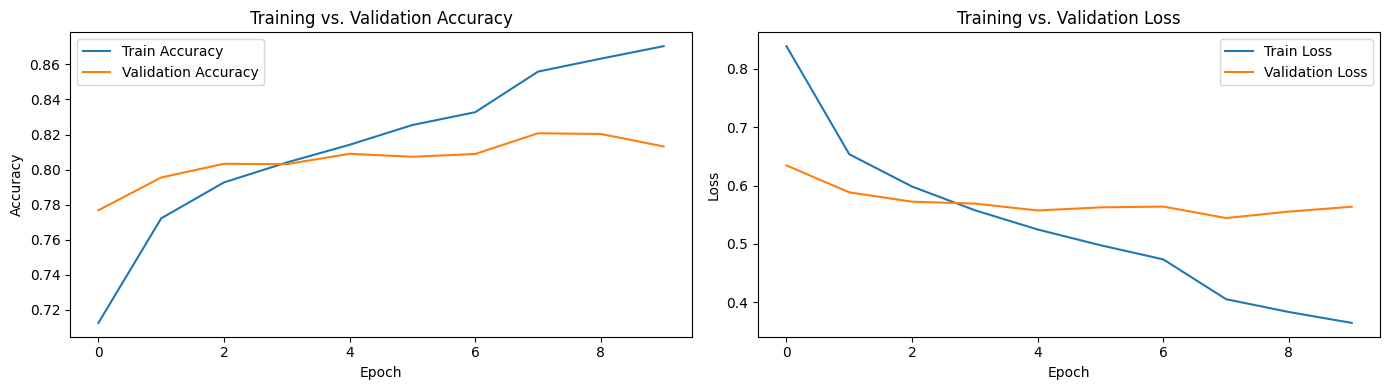

In [13]:
plot_training_history(history)

### Final Evaluation on Test Set

In [14]:
print("\n=== FINAL TEST SET EVALUATION ===")
test_loss, test_accuracy = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")


=== FINAL TEST SET EVALUATION ===
Final Test Loss: 0.5477
Final Test Accuracy: 0.8209


# ***Transfer Leaning Approaches (Fine Tunning)***

## **Step 1: Unfreeze Top Layers of the Base Model**

In [15]:
print("\n===  FINE-TUNING ===")

# Unfreeze the top layers of the base model for fine-tuning
base_model.trainable = True

# Typically, we fine-tune only the later layers
# Let's freeze all the layers except last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Number of layers in base model: {len(base_model.layers)}")
print(f"Number of trainable layers: {sum([l.trainable for l in base_model.layers])}")



===  FINE-TUNING ===
Number of layers in base model: 154
Number of trainable layers: 20


## **Step 2: Compile with a Lower Training Rate**

In [16]:
# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled for fine-tuning with lower learning rate")



Model recompiled for fine-tuning with lower learning rate


## **Step 3: Train and Evaluate Fine-Tuned Model**

In [17]:
# Training

history_fine_tune = model.fit(
    x_train_resized,
    y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 21ms/step - accuracy: 0.6734 - loss: 1.3704 - val_accuracy: 0.7923 - val_loss: 0.6940 - learning_rate: 1.0000e-05
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.7494 - loss: 0.8342 - val_accuracy: 0.7953 - val_loss: 0.6631 - learning_rate: 1.0000e-05
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.7788 - loss: 0.6724 - val_accuracy: 0.7978 - val_loss: 0.6474 - learning_rate: 5.0000e-06


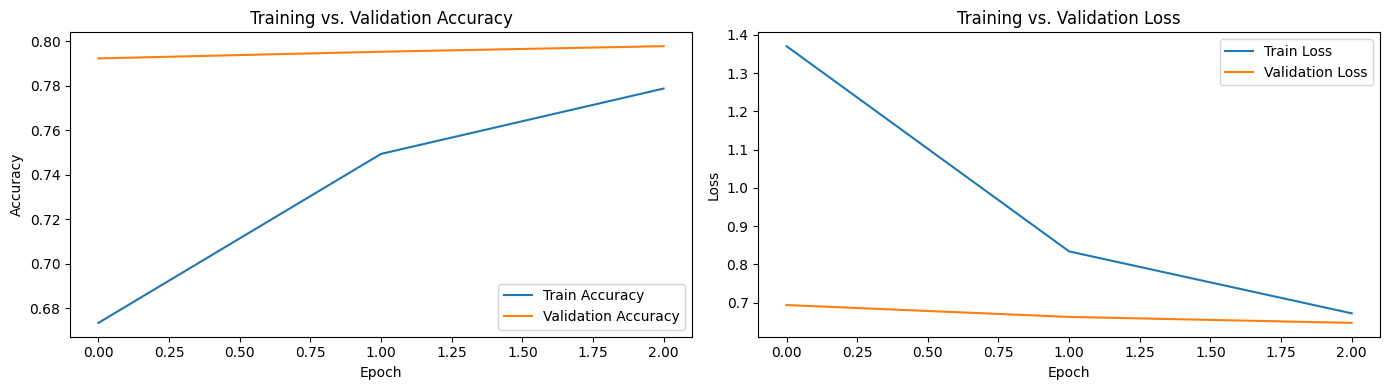

In [18]:
plot_training_history(history_fine_tune)

In [19]:
print("\n=== FINAL TEST SET EVALUATION ===")
test_loss, test_accuracy = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")


=== FINAL TEST SET EVALUATION ===
Final Test Loss: 0.7116
Final Test Accuracy: 0.7874


# ***Data Augmentation (applied to training only)***



## **Step 1: Data Augmentation**

In [20]:
# Create data augmentation pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),  # 5% rotation
    layers.RandomZoom(0.1),      # 10% zoom
    layers.RandomContrast(0.2),  # 20% contrast variation
    # Note: We don't resize since we already resized to 96x96
])

Visualizing augmented images...


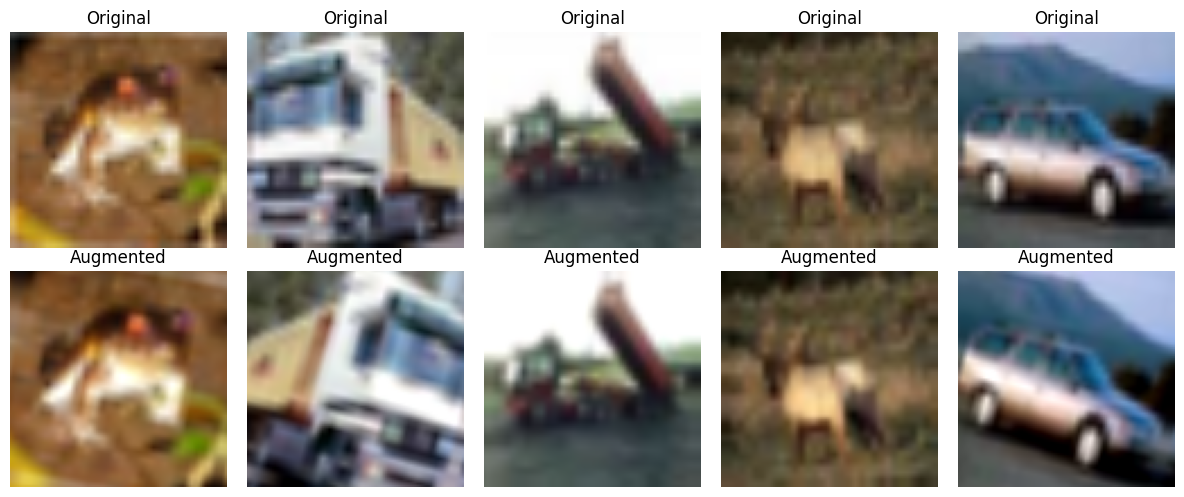

In [21]:
# Let's visualize some augmented images
import matplotlib.pyplot as plt
import numpy as np

print("Visualizing augmented images...")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    # Original image
    axes[0, i].imshow(x_train_resized[i])
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    # Augmented image
    augmented = data_augmentation(tf.expand_dims(x_train_resized[i], 0))
    axes[1, i].imshow(augmented[0])
    axes[1, i].set_title('Augmented')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## **Step 2: Build and Compile Model with Augmentation**

In [22]:
# Build the model with augmentation
inputs = layers.Input(shape=(96, 96, 3))
x = data_augmentation(inputs)  # Apply augmentation
x = base_model(x, training=False)  # Base model frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs, name='mobileNetV2_CIFAR10_augmented')

In [23]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 3: Train and Evaluate with Augmentation**

In [24]:
print("=== TRAINING WITH AUGMENTATION (BASE FROZEN) ===")

# Add callbacks for better training
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

# Train with augmentation
history_augmented = model.fit(
    x_train_resized,  # Note: augmentation happens inside the model
    y_train,
    batch_size=32,
    epochs=10,  # Can do more epochs with augmentation
    shuffle=True,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

=== TRAINING WITH AUGMENTATION (BASE FROZEN) ===
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.7007 - loss: 0.9013 - val_accuracy: 0.6669 - val_loss: 1.1272 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.7710 - loss: 0.6844 - val_accuracy: 0.7319 - val_loss: 1.0754 - learning_rate: 0.0010
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.7923 - loss: 0.6173 - val_accuracy: 0.7332 - val_loss: 1.2420 - learning_rate: 0.0010
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.8108 - loss: 0.5612 - val_accuracy: 0.7925 - val_loss: 0.8888 - learning_rate: 0.0010
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.8236 - loss: 0.5260 - val_accuracy: 0.7806 - val_loss: 0.8983 - learning_rate: 0.0010
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step - accuracy: 0.8367 - loss: 0.4885 - val_accuracy: 0.8046 - val_loss: 0.8132 - learning_rate: 0.0010
Epoch 7/10
1250

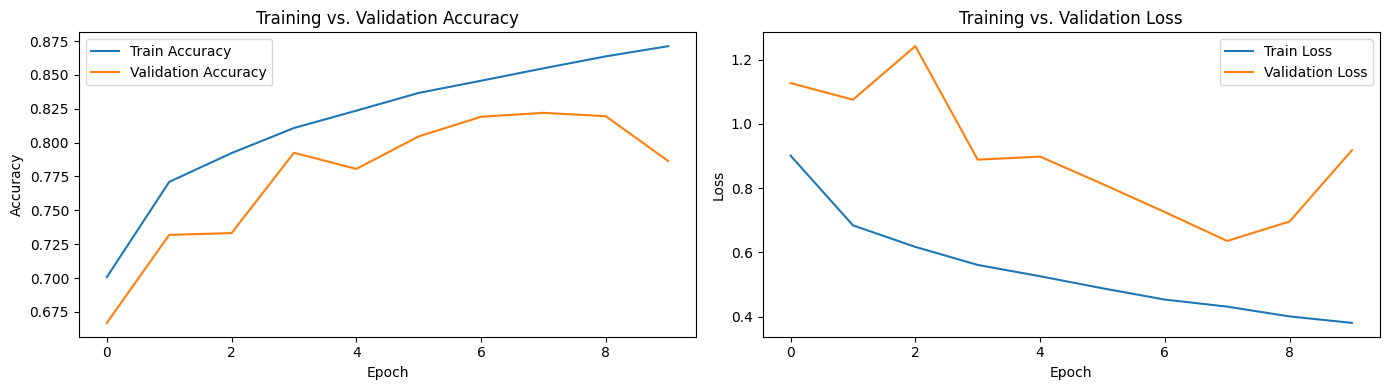

In [25]:
plot_training_history(history_augmented)

In [26]:
# Evaluate
print("\n=== FINAL TEST SET EVALUATION ===")
test_loss_phase1, test_accuracy_phase1 = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Test Loss: {test_loss_phase1:.4f}")
print(f"Test Accuracy: {test_accuracy_phase1:.4f}")


=== FINAL TEST SET EVALUATION ===
Test Loss: 0.6557
Test Accuracy: 0.8165


**Challenge (Optional)**


Explore how different techniques—and combinations of those techniques—impact model performance.

- Compare the results of models that use individual techniques with those that combine multiple approaches.

- How do training and validation accuracy/loss change?
Does combining methods improve generalization?
- Are there trade-offs, such as increased training time or a higher risk of overfitting

Tip: If training takes too long, reduce the batch size and fine-tune fewer layers.